# GLOBAL MENTAL HEALTH ANALYSIS
Mental health data carries secrets about the inner struggles and triumphs of individuals. Exploring such data may reveal surprising insights that could inform public health strategies. If you find this notebook useful, please upvote it.

## Table of Contents

1. [Overview and Data Loading](#Overview-and-Data-Loading)
2. [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
3. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
4. [Predictive Modeling](#Predictive-Modeling)
5. [Discussion and Future Work](#Discussion-and-Future-Work)

In [1]:
# Import necessary libraries with warnings suppressed
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # ensure non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # in case only plt is used
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# Set a seaborn theme for nicer plots
sns.set_theme(style='whitegrid')

## Overview and Data Loading

In this section, we load the Global Mental Health Dataset and take a first glimpse at its structure. We expect data on patient demographics, mental health scores, and treatment outcomes.

In [2]:
# Load the dataset - assuming the CSV is in the declared location
data_path = '/kaggle/input/global-mental-health-dataset-2025/Global_Mental_Health_Dataset_2025.csv'
df = pd.read_csv(data_path, encoding='ascii', delimiter=',')

# Display the first few rows and basic information of the DataFrame
print('DataFrame Head:')
print(df.head(), '\n')

print('DataFrame Info:')
print(df.info())

DataFrame Head:
  Patient_ID  Age  Gender        Country  Depression_Score  Anxiety_Score  \
0     MH0001   56    Male        Germany                 4             10   
1     MH0002   69    Male   South Africa                22              4   
2     MH0003   46    Male   South Africa                 4              2   
3     MH0004   32  Female      Australia                19             16   
4     MH0005   60  Female  United States                14              1   

  Stress_Level  Sleep_Hours Physical_Activity Chronic_Illness  \
0         High          8.2          Moderate              No   
1       Severe          6.2               Low              No   
2          Low         10.4               NaN             Yes   
3          Low         10.0          Moderate              No   
4       Severe          7.9               Low             Yes   

  Mental_Health_History   Treatment  Days_of_Treatment    Outcome Work_Status  
0                    No     Therapy               

## Data Cleaning and Preprocessing

In this section we perform necessary cleaning and preprocessing steps to ensure the data is ready for analysis. Although this dataset does not contain explicit date columns, the focus is on categorical, numerical, and ordinal data.

In [3]:
# Check for missing values
missing_values = df.isnull().sum()
print('Missing values in each column:')
print(missing_values)

# If missing values are found, fill or drop accordingly. For example, here we fill numeric columns with median values
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# For categorical columns, we fill missing with a placeholder
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna('Unknown', inplace=True)

# Optionally drop duplicates if any
df.drop_duplicates(inplace=True)

print('Data cleaning and preprocessing complete.')

Missing values in each column:
Patient_ID                 0
Age                        0
Gender                     0
Country                    0
Depression_Score           0
Anxiety_Score              0
Stress_Level               0
Sleep_Hours                0
Physical_Activity        477
Chronic_Illness            0
Mental_Health_History      0
Treatment                608
Days_of_Treatment          0
Outcome                    0
Work_Status                0
dtype: int64
Data cleaning and preprocessing complete.


## Exploratory Data Analysis

Here we delve into the dataset to search for interesting trends and patterns. The visualizations below include histograms, count plots, correlation analyses, and pair plots. Our aim is to understand distributions, relationships and potential insights within the data.

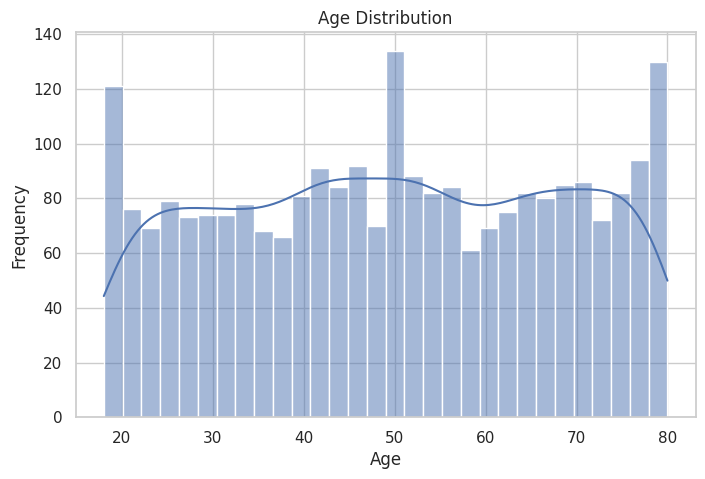

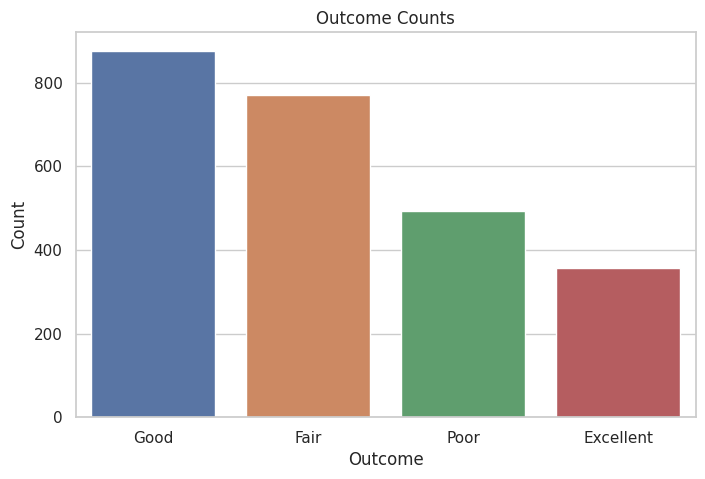

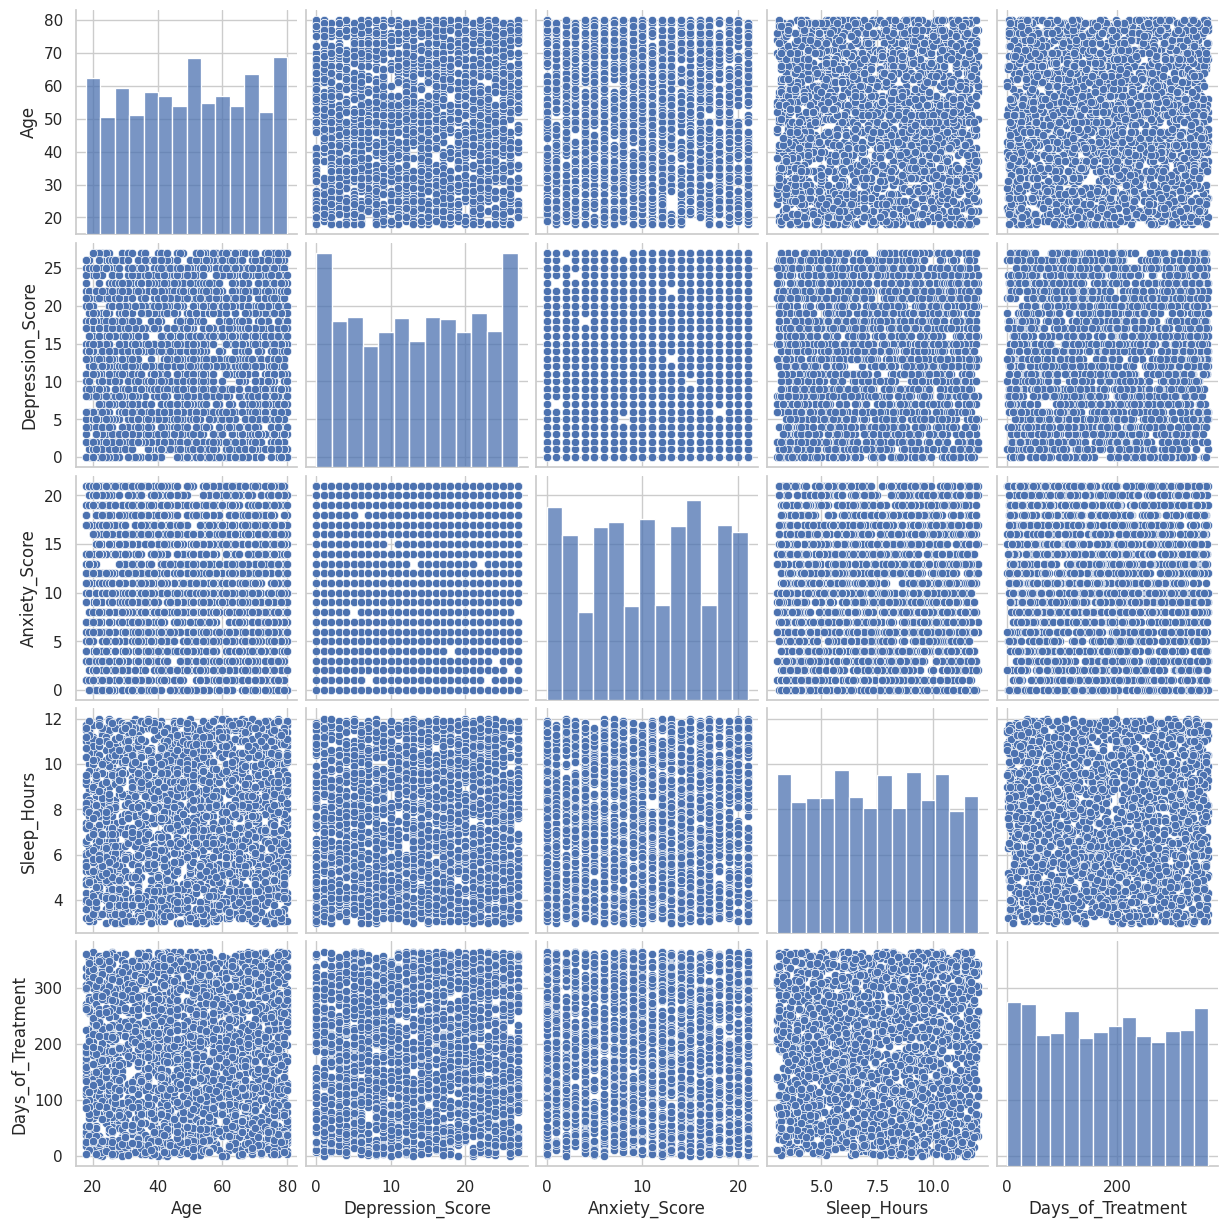

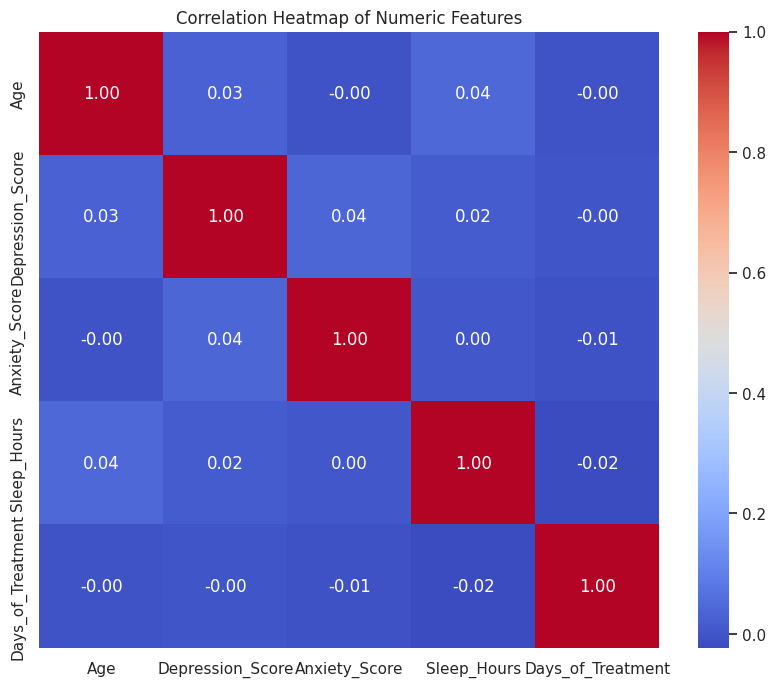

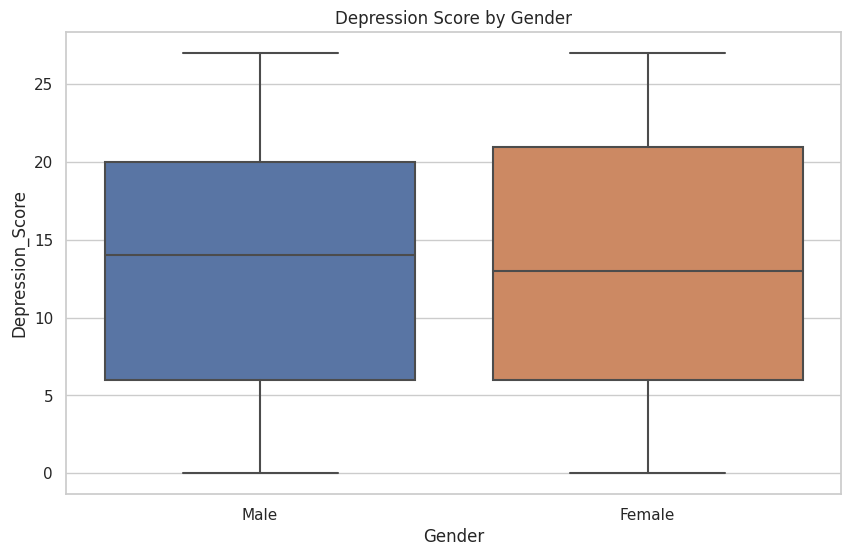

In [4]:
# Plot histogram for Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Plot count plot for Outcome
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Outcome', order=df['Outcome'].value_counts().index)
plt.title('Outcome Counts')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

# Pair Plot for numeric features
numeric_df = df.select_dtypes(include=[np.number])
sns.pairplot(numeric_df)
plt.show()

# If there are four or more numeric columns, plot a correlation heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.show()

# A box plot to inspect the distribution of Depression_Score by Gender
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Gender', y='Depression_Score')
plt.title('Depression Score by Gender')
plt.show()

## Predictive Modeling

In this section we build a predictor to classify the treatment Outcome based on the available features. We will use a Random Forest classifier on a set of predictive numerical features. For demonstration purposes, we focus on features such as Age, Depression Score, Anxiety Score, Sleep Hours, and Days of Treatment. Categorical outcome labels are encoded, and the model's performance is evaluated using accuracy and a confusion matrix.

Prediction Accuracy: 0.292


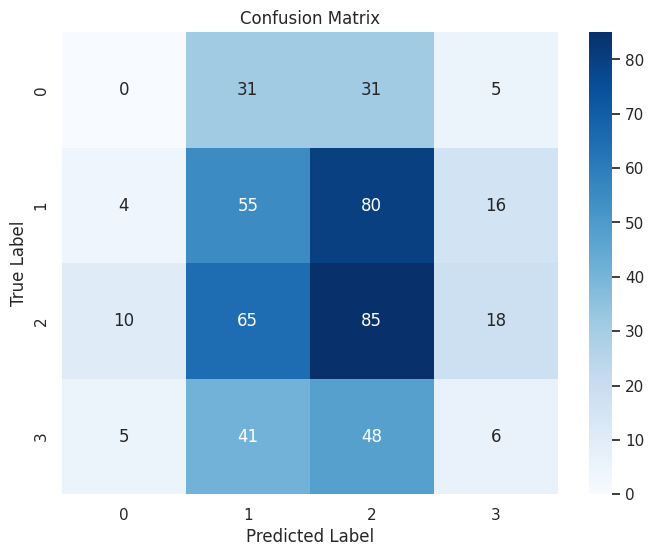

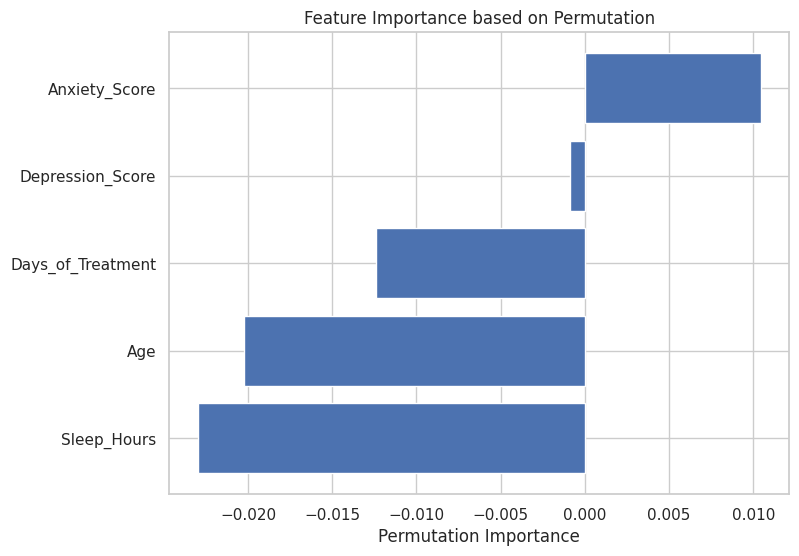

In [5]:
# Prepare data for predictive modeling
# For quick demonstration, we select a few numerical features as predictors
features = ['Age', 'Depression_Score', 'Anxiety_Score', 'Sleep_Hours', 'Days_of_Treatment']
X = df[features]

# Encode the Outcome column into numerical labels
le = LabelEncoder()
y = le.fit_transform(df['Outcome'])

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Prediction Accuracy:', accuracy)

# Generate and display confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Compute permutation importance to understand feature impacts
perm_importance = permutation_importance(rf_clf, X_test, y_test, n_repeats=30, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(8, 6))
plt.barh(range(len(features)), perm_importance.importances_mean[sorted_idx])
plt.yticks(range(len(features)), np.array(features)[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance based on Permutation')
plt.show()

## Discussion and Future Work

The analysis explored the distribution of mental health metrics and examined relationships among them using various visualizations. A Random Forest classifier was developed to predict treatment outcomes with a measured accuracy and an insightful confusion matrix. The permutation importance plot underscored the relative importance of features such as the mental health scores and treatment duration.

Future analyses could include:

- Incorporating additional features through one-hot encoding of categorical columns, such as Gender and Country, to enrich model performance.
- Experimenting with other machine learning models and hyperparameter tuning.
- Analyzing temporal trends if any time series data are available in future datasets.

This notebook has combined rigorous statistical analysis with modern visualization techniques to create an engaging and informative exploration of global mental health data. If you found it useful, please upvote it.